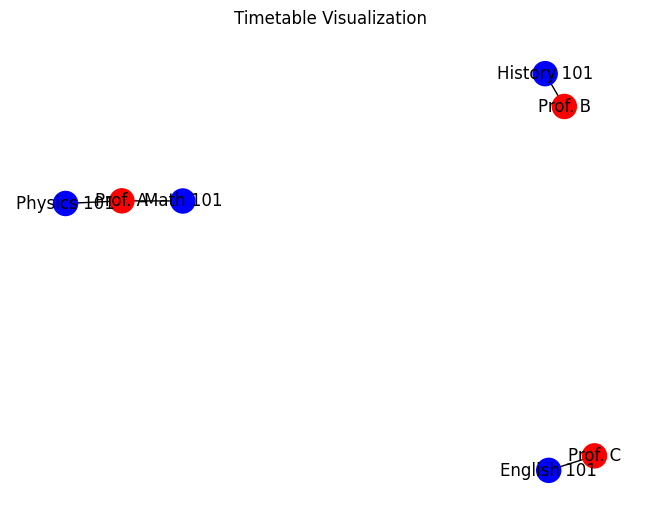

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_timetable(timetable):
    """
    Visualizes the timetable as a graph.

    Args:
        timetable: A dictionary representing the timetable. 
                   Keys are time slots, values are lists of tuples 
                   (professor, class).
    """

    G = nx.Graph()

    # Add nodes for professors and classes
    for time_slot, classes in timetable.items():
        for professor, class_name in classes:
            G.add_node(professor, node_color='red')  # Professors are red
            G.add_node(class_name, node_color='blue')  # Classes are blue

    # Add edges between professors and classes for each time slot
    for time_slot, classes in timetable.items():
        for professor, class_name in classes:
            G.add_edge(professor, class_name)

    # Position nodes using spring layout
    pos = nx.spring_layout(G)

    # Draw the graph
    nx.draw(G, pos, with_labels=True, node_color=[G.nodes[node]['node_color'] for node in G.nodes])

    plt.title("Timetable Visualization")
    plt.show()

# Example usage:
sample_timetable = {
    "9:00-9:50": [("Prof. A", "Math 101"), ("Prof. B", "History 101")],
    "10:00-10:50": [("Prof. A", "Physics 101"), ("Prof. C", "English 101")]
}

visualize_timetable(sample_timetable)

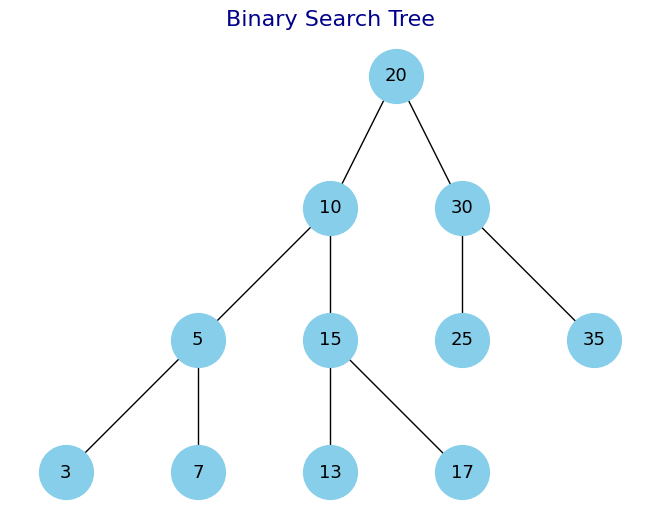

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

class Node:
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None

def insert(root, value):
    if root is None:
        return Node(value)
    else:
        if value < root.value:
            root.left = insert(root.left, value)
        else:
            root.right = insert(root.right, value)
        return root

def plot_tree(root):
    if root is None:
        return
    
    def add_edges(graph, node):
        if node.left:
            graph.add_edge(node.value, node.left.value)
            add_edges(graph, node.left)
        if node.right:
            graph.add_edge(node.value, node.right.value)
            add_edges(graph, node.right)
    
    graph = nx.DiGraph()
    add_edges(graph, root)
    pos = nx.drawing.nx_pydot.graphviz_layout(graph, prog='dot')
    
    # fig, ax = plt.subplots(figsize=(8, 6))
    # ax.set_facecolor('lightblue')  #
    
    nx.draw(
        graph, pos, with_labels=True, arrows=False,
        node_size=1500, node_color='skyblue', font_size=13
    )
    plt.title('Binary Search Tree', fontsize=16, color='darkblue')
    plt.show()

if __name__ == "__main__":
    values = [10, 5, 15, 3, 7, 13, 17, 1, 6, 12, 14, 16, 18]
    b = [20,10,30,5,15,25,35,3,7,13,17]

    root = None
    for value in b:
        root = insert(root, value)
    plot_tree(root)